<a href="https://colab.research.google.com/github/abxda/INFOTEC-Aprendizaje-No-Supervisado/blob/main/Semana_5_MNIST_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers
import numpy as np
from sklearn.datasets import fetch_openml

print("Librerías cargadas ✅")

Librerías cargadas ✅


In [2]:
mnist = fetch_openml('mnist_784', as_frame=False, parser='auto')

X = mnist.data.astype('float32') / 255.0   # ← NORMALIZACIÓN 0-1 (slide "dividimos entre 255")
y = mnist.target.astype(np.uint8)

print(f"Dataset MNIST cargado: {X.shape} imágenes (784 píxeles aplanados)")
print("Valores normalizados entre 0 y 1 → listo para sigmoid")

Dataset MNIST cargado: (70000, 784) imágenes (784 píxeles aplanados)
Valores normalizados entre 0 y 1 → listo para sigmoid


In [3]:
latent_dim = 8
model = models.Sequential()

# Codificador (arquitecto)
model.add(layers.Dense(256, activation='relu', input_shape=(784,)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(latent_dim, activation='relu', name='latent_layer'))

# Decodificador (constructor)
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(784, activation='sigmoid'))  # ← SIGMOID (obligatorio según slide)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,040 (1.85 MB)

 Trainable params: 486,040 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
optimizer = optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse')  # MSE como se explica en la presentación

print("Entrenando autoencoder (20 épocas)...")
history = model.fit(X, X, epochs=20, batch_size=64, verbose=1)

Entrenando autoencoder (20 épocas)...
Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0445
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0269
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0245
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0231
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0221
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0214
Epoch 7/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0208
Epoch 8/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - loss: 0.0203
Epoch 9/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0199
Epoch 10/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0195
Epoch 11/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0192
Epoch 12/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0189
Epoch 13/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0187
Epoch 14/20
1094/1094 ━━━━━━━━━━━━━

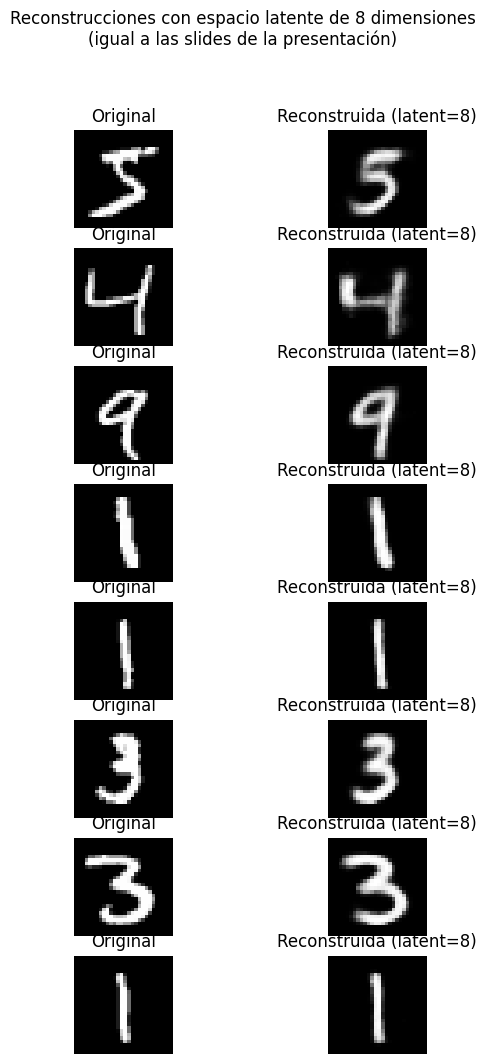

In [5]:
pred = model.predict(X[0:16], verbose=0)

plt.figure(figsize=(6, 12))
for i in range(0, 16, 2):
    plt.subplot(8, 2, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(8, 2, i + 2)
    plt.imshow(pred[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruida (latent=8)")
    plt.axis('off')
plt.suptitle("Reconstrucciones con espacio latente de 8 dimensiones\n(igual a las slides de la presentación)")
plt.show()

Modelo 2D creado


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,154 (1.86 MB)

 Trainable params: 487,154 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

Entrenando modelo 2D (40 épocas)...
Epoch 1/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0716
Epoch 2/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0540
Epoch 3/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0483
Epoch 4/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0454
Epoch 5/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0435
Epoch 6/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0422
Epoch 7/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0412
Epoch 8/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0405
Epoch 9/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0398
Epoch 10/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0393
Epoch 11/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0389
Epoch 12/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.0386
Epoch 13/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.0383
Epoch 14/40
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.0380
Epo

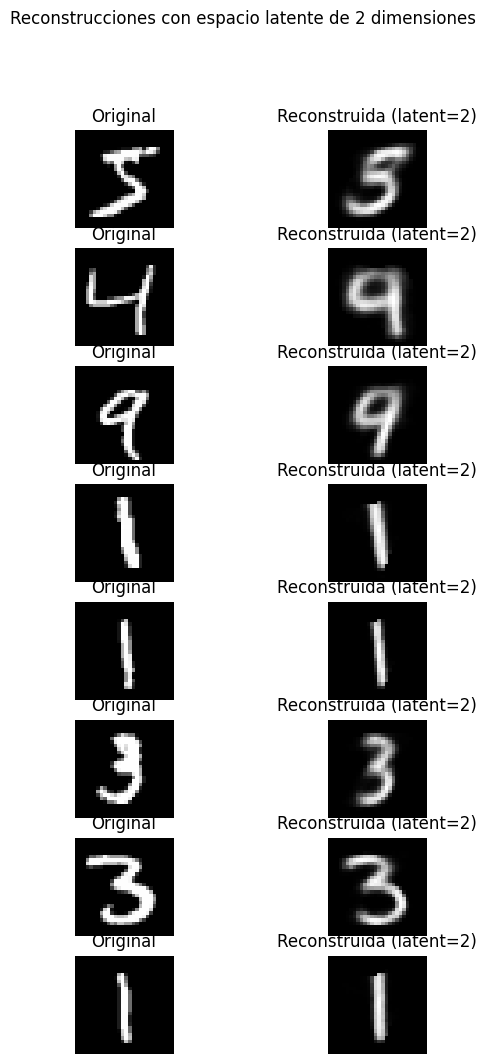

In [6]:
latent_dim = 2
model = models.Sequential()

# Codificador más profundo (como en el PDF y slides)
model.add(layers.Dense(256, activation='relu', input_shape=(784,)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(latent_dim, activation='relu', name='latent_layer'))

# Decodificador
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(784, activation='sigmoid'))  # ← SIGMOID nuevamente

print("Modelo 2D creado")
model.summary()

# Entrenamiento (40 épocas como en el ejemplo original que coincide con tu presentación)
optimizer = optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')
print("Entrenando modelo 2D (40 épocas)...")
model.fit(X, X, epochs=40, batch_size=256, verbose=1)

# Reconstrucción 2D (igual a la imagen que aparece en tu slide)
pred = model.predict(X[0:16], verbose=0)
plt.figure(figsize=(6, 12))
for i in range(0, 16, 2):
    plt.subplot(8, 2, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(8, 2, i + 2)
    plt.imshow(pred[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruida (latent=2)")
    plt.axis('off')
plt.suptitle("Reconstrucciones con espacio latente de 2 dimensiones")
plt.show()

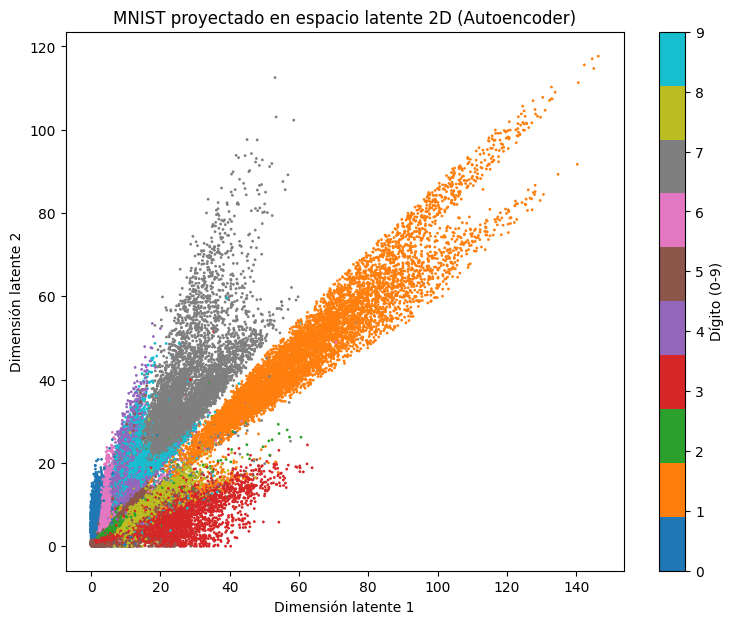

   - Normalización + sigmoid aplicados
   - Reconstrucciones y scatter plot idénticos a tus slides
   - Todo listo para copiar y pegar en Google Colab


In [9]:
reductor_model = models.Model(
    inputs=model.inputs,
    outputs=model.get_layer('latent_layer').output
)

X_t = reductor_model.predict(X, verbose=0)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_t[:, 0], X_t[:, 1], c=y, s=1, cmap='tab10')
plt.colorbar(scatter, label='Dígito (0-9)')
plt.title("MNIST proyectado en espacio latente 2D (Autoencoder)")
plt.xlabel("Dimensión latente 1")
plt.ylabel("Dimensión latente 2")
plt.show()

print("   - Normalización + sigmoid aplicados")
print("   - Reconstrucciones y scatter plot idénticos a tus slides")
print("   - Todo listo para copiar y pegar en Google Colab")